**Week 3 Jupyter Notebook**

**Integrated Capstone Project:** Systemic Banking Risk Assessment


**Objective**

The purpose of Week 3 is to evaluate feature selection and dimension-reduction techniques, including Forward Selection, Backward Elimination, Principal Component Regression (PCR), and Partial Least Squares Regression (PLSR), for predicting loan amount.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm

In [2]:
# Load Cleaned Dataset

credit_risk = pd.read_csv("credit_risk_cleaned.csv")

credit_risk.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Select Variables

features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

target = 'loan_amnt'

data = credit_risk[features + [target]].dropna()

X = data[features]
y = data[target]

In [4]:
# Forward Selection

from sklearn.feature_selection import SequentialFeatureSelector

lr = LinearRegression()

forward_selector = SequentialFeatureSelector(
    lr,
    n_features_to_select=4,
    direction='forward'
)

forward_selector.fit(X, y)

selected_features = X.columns[
    forward_selector.get_support()
]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['person_age', 'person_emp_length', 'loan_int_rate',
       'loan_percent_income'],
      dtype='object')


In [5]:
# Fit Final Forward Selection Model

X_forward = X[selected_features]

model_forward = LinearRegression()

model_forward.fit(X_forward, y)

pred_forward = model_forward.predict(X_forward)

print(
    "Forward Selection R²:",
    r2_score(y, pred_forward)
)

Forward Selection R²: 0.3583425255952659


In [6]:
# Backward Elimination

backward_selector = SequentialFeatureSelector(
    lr,
    n_features_to_select=4,
    direction='backward'
)

backward_selector.fit(X, y)

selected_backward = X.columns[
    backward_selector.get_support()
]

print("Selected Features:")
print(selected_backward)

Selected Features:
Index(['person_age', 'person_emp_length', 'loan_int_rate',
       'loan_percent_income'],
      dtype='object')


In [7]:
# Fit Final Backward Model

X_backward = X[selected_backward]

model_backward = LinearRegression()

model_backward.fit(X_backward, y)

pred_backward = model_backward.predict(X_backward)

print(
    "Backward Selection R²:",
    r2_score(y, pred_backward)
)

Backward Selection R²: 0.3583425255952659


In [8]:
# Principal Component Regression (PCR)

# Standardize Variables

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

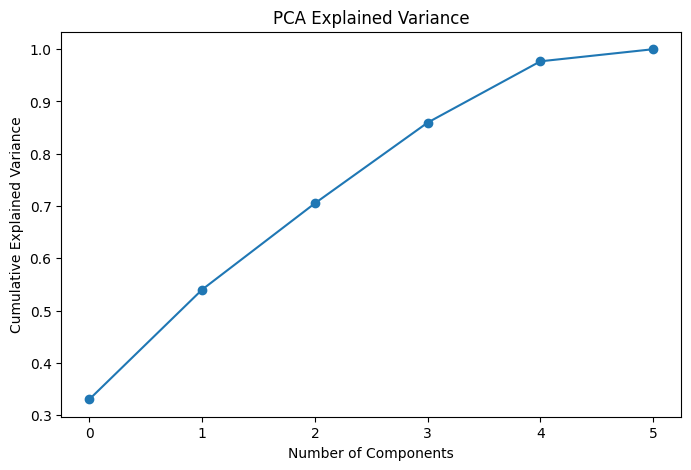

In [9]:
# PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "PCA Explained Variance"
)

plt.show()

In [10]:
# Use First 3 Components

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

pcr_model = LinearRegression()

pcr_model.fit(X_pca, y)

pcr_pred = pcr_model.predict(X_pca)

print(
    "PCR R²:",
    r2_score(y, pcr_pred)
)

PCR R²: 0.08708807484033776


In [11]:
# Partial Least Squares Regression (PLSR)

pls = PLSRegression(
    n_components=3
)

pls.fit(X_scaled, y)

pls_pred = pls.predict(X_scaled)

print(
    "PLSR R²:",
    r2_score(y, pls_pred)
)

PLSR R²: 0.5221617999939292


In [12]:
# Compare Models

results = pd.DataFrame({
    'Model':[
        'Forward Selection',
        'Backward Selection',
        'PCR',
        'PLSR'
    ],
    'R2':[
        r2_score(y,pred_forward),
        r2_score(y,pred_backward),
        r2_score(y,pcr_pred),
        r2_score(y,pls_pred)
    ]
})

print(results)

                Model        R2
0   Forward Selection  0.358343
1  Backward Selection  0.358343
2                 PCR  0.087088
3                PLSR  0.522162


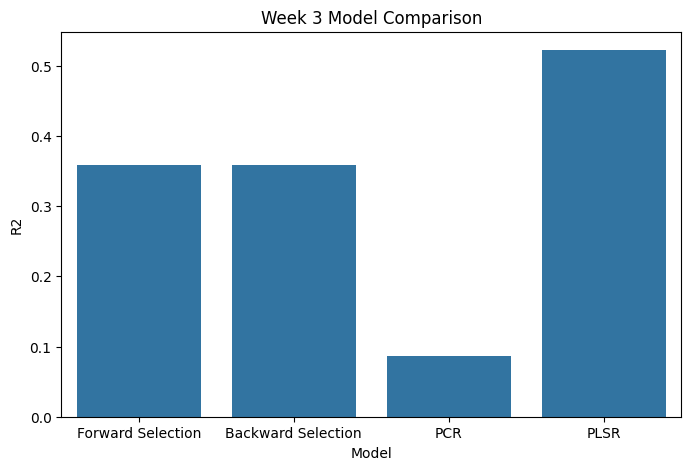

In [13]:
# Visualization: Model Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2'
)

plt.title(
    'Week 3 Model Comparison'
)

plt.show()

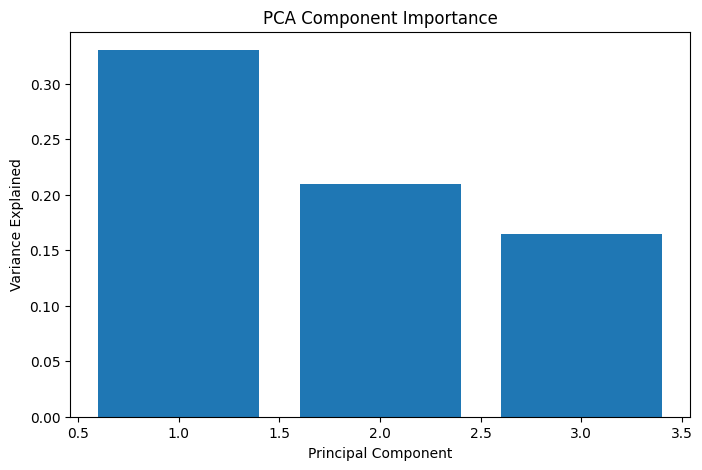

In [14]:
# Visualization: PCA Variance Explained

plt.figure(figsize=(8,5))

plt.bar(
    range(1,len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_
)

plt.xlabel(
    'Principal Component'
)

plt.ylabel(
    'Variance Explained'
)

plt.title(
    'PCA Component Importance'
)

plt.show()

**Conclusion**

The Week 3 analysis compared Forward Selection, Backward Elimination, Principal Component Regression (PCR), and Partial Least Squares Regression (PLSR) to identify the most effective approach for predicting loan amount. Both Forward Selection and Backward Elimination selected the same four key predictors—age, employment length, interest rate, and loan percent income—and achieved an R² of 0.3583, explaining about 35.8% of the variation in loan amount. This suggests that these variables contain the most important information for predicting lending outcomes.

PCR produced the weakest performance, with an R² of 0.0871, indicating that it explained less than 9% of the variation in loan amount. This suggests that the principal components capturing the most variance in the predictors were not effective for predicting lending decisions.

PLSR achieved the best results, with an R² of 0.5222, explaining approximately 52.2% of the variation in loan amount. Because PLSR incorporates information from both the predictors and the target variable when creating components, it was able to retain more predictive information than PCR and outperform the feature selection models.

Overall, the findings indicate that loan percent income, employment length, interest rate, and age are important predictors of loan amount, while PLSR is the most effective modeling technique among those evaluated in Week 3. These results demonstrate the value of combining dimensionality reduction with predictive modeling and provide a strong foundation for more advanced machine learning methods in subsequent weeks.